<a href="https://colab.research.google.com/github/Anupampal1992/Group-Project/blob/EDA/Traffic_Accident.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone  https://github.com/Anupampal1992/Group-Project.git
%cd Group-Project
!ls

Cloning into 'Group-Project'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 59 (delta 34), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 219.59 KiB | 1.60 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/Group-Project
 Traffic_Accident.ipynb  'Traffic Accident Severity Predictor Dataset.csv'


In [3]:

!git status


On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [4]:
import pandas as pd
import numpy as np

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

#preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.spatial import transform


#Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score

#Evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score,accuracy_score

#Pipeline
from sklearn.pipeline import Pipeline

#Compute Class Weight
from sklearn.utils.class_weight import compute_class_weight



In [5]:
df=pd.read_csv('Traffic Accident Severity Predictor Dataset.csv')  #Loading the data from Github
df.head(5)

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1


EDA

In [6]:
df.shape

(20000, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               19958 non-null  object 
 1   Road_Type             19958 non-null  object 
 2   Time_of_Day           19958 non-null  object 
 3   Traffic_Density       19958 non-null  float64
 4   Speed_Limit           19958 non-null  float64
 5   Number_of_Vehicles    19958 non-null  float64
 6   Driver_Alcohol        19958 non-null  float64
 7   Accident_Severity     19958 non-null  object 
 8   Road_Condition        19958 non-null  object 
 9   Vehicle_Type          19958 non-null  object 
 10  Driver_Age            19958 non-null  float64
 11  Driver_Experience     19958 non-null  float64
 12  Road_Light_Condition  19958 non-null  object 
 13  Accident              20000 non-null  int64  
dtypes: float64(6), int64(1), object(7)
memory usage: 2.1+ MB


In [8]:
df.describe()

,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Accident
count,19958.000000,19958.000000,19958.000000,19958.000000,19958.000000,19958.000000,20000.000000
mean,1.010923,71.448943,3.282694,0.164445,43.146758,38.859154,0.292000
std,0.783966,32.366260,1.999111,0.370688,15.099349,15.249536,0.454694
min,0.000000,30.000000,1.000000,0.000000,18.000000,9.000000,0.000000
25%,0.000000,50.000000,2.000000,0.000000,30.000000,26.000000,0.000000
50%,1.000000,60.000000,3.000000,0.000000,43.000000,39.000000,0.000000
75%,2.000000,80.000000,4.000000,0.000000,56.000000,52.000000,1.000000
max,2.000000,213.000000,14.000000,1.000000,69.000000,69.000000,1.000000


In [9]:
df['Accident_Severity'].value_counts()  #Target variable

,count
Accident_Severity,
Low,11862
Moderate,6090
High,2006


In [10]:
df.isnull().sum()   #cheacking the null value

,0
Weather,42
Road_Type,42
Time_of_Day,42
Traffic_Density,42
Speed_Limit,42
Number_of_Vehicles,42
Driver_Alcohol,42
Accident_Severity,42
Road_Condition,42
Vehicle_Type,42


In [11]:
df.duplicated().sum()  #checking the duplicate values

np.int64(15)

In [12]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

Accident_Severity
Low         11852
Moderate     6087
High         2005
Name: count, dtype: int64


<Axes: xlabel='Accident_Severity'>

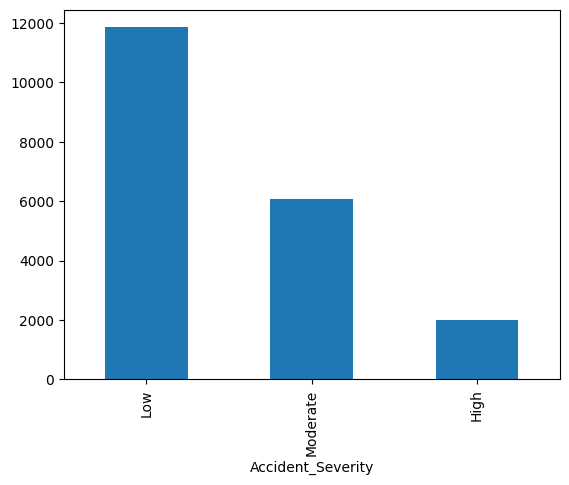

In [13]:
print(df["Accident_Severity"].value_counts()) # Evaluating the Target Column
df["Accident_Severity"].value_counts().plot(kind='bar')

In [14]:
#Separating the numerical and categorical columns
num_col=df.select_dtypes(include=['int64','float64']).columns
cat_col=df.select_dtypes(include=['object']).columns

Plotting the graph for all Numerical Columns as per our target\

In [15]:
# Fillig the missing values
df[num_col] = df[num_col].fillna(df[num_col].median())
df[cat_col] = df[cat_col].fillna(df[cat_col].mode().iloc[0])   #.mode() returns a DataFrame (or Series with multiple values), but fillna() needs a single value per column.
print("Numerical Coulumns", df[num_col].columns)
print("Categorical Columns", df[cat_col].columns)
df.isnull().sum()

Numerical Coulumns Index(['Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles',
       'Driver_Alcohol', 'Driver_Age', 'Driver_Experience', 'Accident'],
      dtype='object')
Categorical Columns Index(['Weather', 'Road_Type', 'Time_of_Day', 'Accident_Severity',
       'Road_Condition', 'Vehicle_Type', 'Road_Light_Condition'],
      dtype='object')


,0
Weather,0
Road_Type,0
Time_of_Day,0
Traffic_Density,0
Speed_Limit,0
Number_of_Vehicles,0
Driver_Alcohol,0
Accident_Severity,0
Road_Condition,0
Vehicle_Type,0


**Feature and target separation**

In [16]:
x=df.drop(columns=['Accident_Severity', 'Accident'], axis=1)
y=df['Accident_Severity']
print(x.shape)
print(y.shape)
x.columns

(19985, 12)
(19985,)


Index(['Weather', 'Road_Type', 'Time_of_Day', 'Traffic_Density', 'Speed_Limit',
       'Number_of_Vehicles', 'Driver_Alcohol', 'Road_Condition',
       'Vehicle_Type', 'Driver_Age', 'Driver_Experience',
       'Road_Light_Condition'],
      dtype='object')

In [17]:
y.count()

np.int64(19985)

In [18]:

print("Clases of Target Variable:", y.value_counts())


Clases of Target Variable: Accident_Severity
Low         11893
Moderate     6087
High         2005
Name: count, dtype: int64


In [19]:
order = {'Low': 0, 'Moderate': 1, 'High': 2}
y = y.map(order)
y

,Accident_Severity
0,0
1,1
2,0
3,0
4,0
...,...
19995,1
19996,1
19997,1
19998,0


In [20]:
#get the numerical features and categorical features without Target variable
numerical_features = x.select_dtypes(include=['int64', 'float64']).columns
categorical_features = x.select_dtypes(include=['object']).columns
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: Index(['Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles',
       'Driver_Alcohol', 'Driver_Age', 'Driver_Experience'],
      dtype='object')
Categorical Features: Index(['Weather', 'Road_Type', 'Time_of_Day', 'Road_Condition', 'Vehicle_Type',
       'Road_Light_Condition'],
      dtype='object')


In [21]:
# Apply different processing step to different columns group
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
categorical_features


Index(['Weather', 'Road_Type', 'Time_of_Day', 'Road_Condition', 'Vehicle_Type',
       'Road_Light_Condition'],
      dtype='object')

**Split and Train the data**

In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42,  stratify=y
)

print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
y_train.value_counts()

Shape of x_train: (15988, 12)
Shape of x_test: (3997, 12)
Shape of y_train: (15988,)
Shape of y_test: (3997,)


,count
Accident_Severity,
0,9514
1,4870
2,1604


**Applying Models**

In [23]:
#Logistic regression
lr = Pipeline(steps=[('preprocessor', preprocessor),
                     ('classifier', LogisticRegression(max_iter=1000))])

lr=lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("accuracy:\n", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[2379    0    0]
 [1217    0    0]
 [ 401    0    0]]
accuracy:
 0.5951963972979735
Classification Report:
               precision    recall  f1-score   support

           0       0.60      1.00      0.75      2379
           1       0.00      0.00      0.00      1217
           2       0.00      0.00      0.00       401

    accuracy                           0.60      3997
   macro avg       0.20      0.33      0.25      3997
weighted avg       0.35      0.60      0.44      3997



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
#Random Forest

rf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', RandomForestClassifier(
                          class_weight='balanced_subsample',
                          n_estimators=300,
                          max_depth=None,
                          min_samples_split=5,
                          min_samples_leaf=2,
                          random_state=42,

                      ))])

rf = rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

print("confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("accuracy:\n", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


confusion Matrix:
 [[2092  269   18]
 [1069  144    4]
 [ 359   40    2]]
accuracy:
 0.5599199399549663
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.88      0.71      2379
           1       0.32      0.12      0.17      1217
           2       0.08      0.00      0.01       401

    accuracy                           0.56      3997
   macro avg       0.33      0.33      0.30      3997
weighted avg       0.46      0.56      0.48      3997



**Compute class weights**

In [25]:
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced', classes=classes, y=y_train
)

weight_map = dict(zip(classes, class_weights))
sample_weights = y_train.map(weight_map)
sample_weights

,Accident_Severity
19336,0.560157
4473,1.094319
12225,0.560157
11744,0.560157
13993,0.560157
...,...
15240,1.094319
4955,3.322527
12429,0.560157
19357,0.560157


In [26]:
# XGBoost Model
xgb = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', XGBClassifier(
                          objective='multi:softmax',
                         num_class=3,
                          eval_metric='mlogloss',
                          max_depth=5,
                          sub_sample=0.8,
                          colsample_bytree=0.8,

                          n_estimators=300,
                          learning_rate=0.05
                      ))])

xgb.fit(x_train, y_train, classifier__sample_weight=sample_weights)
y_pred = xgb.predict(x_test)
y_prob = xgb.predict_proba(x_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("accuracy:\n", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:17:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "sub_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:
 [[985 774 620]
 [493 412 312]
 [156 140 105]]
accuracy:
 0.37578183637728296
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.41      0.49      2379
           1       0.31      0.34      0.32      1217
           2       0.10      0.26      0.15       401

    accuracy                           0.38      3997
   macro avg       0.34      0.34      0.32      3997
weighted avg       0.46      0.38      0.41      3997



**Applying threshold**

In [27]:
for t in [0.4,0.5,0.6,0.7,0.8,0.9,0.95]:
    weights = np.array([1, 1, t])
    preds = np.argmax(y_prob / weights, axis=1)
    print(f"\nThreshold = {t}")
    print(("F1 Score:"),f1_score(y_test, preds, average='weighted'))
    print(("Accuracy_metrics:"),accuracy_score(y_test, preds))
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))



Threshold = 0.4
F1 Score: 0.09096288839292392
Accuracy_metrics: 0.1330998248686515
[[ 119   89 2171]
 [  62   39 1116]
 [  18    9  374]]
              precision    recall  f1-score   support

           0       0.60      0.05      0.09      2379
           1       0.28      0.03      0.06      1217
           2       0.10      0.93      0.18       401

    accuracy                           0.13      3997
   macro avg       0.33      0.34      0.11      3997
weighted avg       0.45      0.13      0.09      3997


Threshold = 0.5
F1 Score: 0.13378557172646388
Accuracy_metrics: 0.15286464848636477
[[ 196  137 2046]
 [ 107   71 1039]
 [  34   23  344]]
              precision    recall  f1-score   support

           0       0.58      0.08      0.14      2379
           1       0.31      0.06      0.10      1217
           2       0.10      0.86      0.18       401

    accuracy                           0.15      3997
   macro avg       0.33      0.33      0.14      3997
weighted avg  

In [28]:
FINAL_THRESHOLD = .8

y_pred_final = np.argmax(y_prob / [1, 1, FINAL_THRESHOLD], axis=1)

print(f1_score(y_test, y_pred_final, average='weighted'))
print(confusion_matrix(y_test, y_pred_final))
print(accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

0.31720124693693874
[[ 653  503 1223]
 [ 340  269  608]
 [ 116   95  190]]
0.27820865649236926
              precision    recall  f1-score   support

           0       0.59      0.27      0.37      2379
           1       0.31      0.22      0.26      1217
           2       0.09      0.47      0.16       401

    accuracy                           0.28      3997
   macro avg       0.33      0.32      0.26      3997
weighted avg       0.45      0.28      0.32      3997



**Feature Importance**

In [29]:
#Get the trained XGBoost model from Pipeline
xgb_model = xgb.named_steps['classifier']

#Extract feature names after preprocessing
preprocessor = xgb.named_steps['preprocessor']
numerical_features = preprocessor.transformers_[0][2]
categorical_features = preprocessor.transformers_[1][2]
ohe = preprocessor.transformers_[1][1]
categorical_features = ohe.get_feature_names_out(categorical_features)
feature_names = list(numerical_features) + list(categorical_features)

len(feature_names) == len(xgb_model.feature_importances_)

True

**Create Feature Importance DataFrame**

In [30]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df

,Feature,Importance
29,Road_Light_Condition_No Light,0.043807
12,Road_Type_Highway,0.037970
15,Time_of_Day_Afternoon,0.037099
26,Vehicle_Type_Truck,0.036363
20,Road_Condition_Icy,0.036339
27,Road_Light_Condition_Artificial Light,0.036130
8,Weather_Rainy,0.035959
22,Road_Condition_Wet,0.035889
23,Vehicle_Type_Bus,0.035689
9,Weather_Snowy,0.035616


In [31]:
#View Top Important Features

importance_df.head(10)

,Feature,Importance
29,Road_Light_Condition_No Light,0.043807
12,Road_Type_Highway,0.037970
15,Time_of_Day_Afternoon,0.037099
26,Vehicle_Type_Truck,0.036363
20,Road_Condition_Icy,0.036339
27,Road_Light_Condition_Artificial Light,0.036130
8,Weather_Rainy,0.035959
22,Road_Condition_Wet,0.035889
23,Vehicle_Type_Bus,0.035689
9,Weather_Snowy,0.035616
